# Train DeepLabV3+ phân đoạn polyp nội soi — bản gọn để chạy lại trên GPU

Notebook này **không tải lại hoặc chuẩn hoá lại dữ liệu**. Nó dùng các artifact đã có trên Google Drive:

- `data/manifests/train.csv`
- `data/manifests/validation.csv`
- `data/manifests/internal_test.csv`
- `data/manifests/external_test_etis.csv`
- `data/prepared_png/`

Luồng chạy: mount Drive → copy PNG sang `/content` → đọc split → tf.data → DeepLabV3+ → warm-up → fine-tune → threshold → evaluate.

> ETIS-Larib được giữ riêng làm external test với **190 mẫu sạch**. Không dùng ETIS để train, validation hoặc chọn threshold.


In [ ]:
# [Mục đích ô này] Khởi tạo môi trường GPU, import thư viện, mount Drive
# và khai báo cấu hình/path cần để tiếp tục train.

import os
import re
import gc
import json
import math
import random
import shutil
import hashlib
import subprocess
from pathlib import Path
from typing import Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    print("Không phát hiện Google Colab; notebook sẽ dùng đường dẫn local.")

SEED = 2026
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    raise RuntimeError("TensorFlow chưa nhận GPU. Hãy đổi Runtime sang GPU rồi chạy lại từ đầu.")

PROJECT_ROOT = Path("/content/drive/MyDrive/deeplabv3_stomach")
DEEPLAB_ROOT = PROJECT_ROOT / "deeplabv3plus_polyp"

DATA_ROOT = DEEPLAB_ROOT / "data"
PREPARED_ROOT = DATA_ROOT / "prepared_png"
MANIFEST_ROOT = DATA_ROOT / "manifests"
MODEL_ROOT = DEEPLAB_ROOT / "models"
OUTPUT_ROOT = DEEPLAB_ROOT / "outputs"
FIGURE_ROOT = OUTPUT_ROOT / "figures"

for folder in [MODEL_ROOT, OUTPUT_ROOT, FIGURE_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)

# Bắt đầu với batch 2 để an toàn cho DeepLabV3+ ResNet50 ở kích thước 352.
# Sau khi train ổn không OOM, có thể thử tăng lên 4.
IMAGE_SIZE = 352
BATCH_SIZE = 2
WARMUP_EPOCHS = 6
FINE_TUNE_EPOCHS = 45
PATIENCE = 10

required_files = [
    MANIFEST_ROOT / "train.csv",
    MANIFEST_ROOT / "validation.csv",
    MANIFEST_ROOT / "internal_test.csv",
    MANIFEST_ROOT / "external_test_etis.csv",
]

missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Thiếu split manifest. Cần chạy notebook chuẩn bị dữ liệu trước: " + ", ".join(missing_files)
    )

print("TensorFlow:", tf.__version__)
print("GPU:", gpus)
print("IMAGE_SIZE:", IMAGE_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("PREPARED_ROOT:", PREPARED_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
IMAGE_SIZE: 352
BATCH_SIZE: 2
PREPARED_ROOT: /content/drive/MyDrive/deeplabv3_stomach/deeplabv3plus_polyp/data/prepared_png


In [ ]:
# [Mục đích ô này] Sao chép ảnh/mask PNG đã chuẩn hoá từ Google Drive sang ổ đĩa cục bộ
# để tránh nghẽn I/O khi train. Chỉ chạy nhanh ở những lần sau nếu file local đã có.

LOCAL_PREPARED_ROOT = Path("/content/deeplabv3plus_prepared_png")
LOCAL_PREPARED_ROOT.mkdir(parents=True, exist_ok=True)

if not PREPARED_ROOT.exists():
    raise FileNotFoundError(f"Không tìm thấy prepared data trên Drive: {PREPARED_ROOT}")

print("Đồng bộ prepared PNG từ Drive sang local runtime...")
subprocess.run(
    [
        "rsync",
        "-a",
        "--info=progress2",
        f"{PREPARED_ROOT}/",
        f"{LOCAL_PREPARED_ROOT}/",
    ],
    check=True,
)

def remap_to_local_prepared_path(path_value: str) -> str:
    drive_path = Path(path_value)
    try:
        relative_path = drive_path.relative_to(PREPARED_ROOT)
    except ValueError as error:
        raise ValueError(
            f"Đường dẫn prepared không thuộc PREPARED_ROOT: {drive_path}"
        ) from error

    local_path = LOCAL_PREPARED_ROOT / relative_path
    if not local_path.exists():
        raise FileNotFoundError(f"Thiếu file sau khi đồng bộ local: {local_path}")
    return str(local_path)

def load_split(split_name: str) -> pd.DataFrame:
    frame = pd.read_csv(MANIFEST_ROOT / f"{split_name}.csv")
    for column in ["prepared_image_path", "prepared_mask_path"]:
        frame[column] = frame[column].astype(str).map(remap_to_local_prepared_path)
    return frame.reset_index(drop=True)

train_df = load_split("train")
val_df = load_split("validation")
internal_test_df = load_split("internal_test")
etis_test_df = load_split("external_test_etis")
benchmark_train_pool = load_split("benchmark_train_pool")

assert len(train_df) == 1305
assert len(val_df) == 145
assert len(internal_test_df) == 162
assert len(etis_test_df) == 190
assert len(benchmark_train_pool) == 1450

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Internal test:", len(internal_test_df))
print("External test ETIS sạch:", len(etis_test_df))


Đồng bộ prepared PNG từ Drive sang local runtime...
Train: 1305
Validation: 145
Internal test: 162
External test ETIS sạch: 190


In [ ]:
# [Mục đích ô này] Kiểm tra nhanh ảnh-mask-overlay ở mọi split trước khi train.

def show_samples(frame: pd.DataFrame, n: int = 3, seed: int = SEED) -> None:
    examples = frame.sample(n=min(n, len(frame)), random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(len(examples), 3, figsize=(12, 4 * len(examples)))
    if len(examples) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index, row in examples.iterrows():
        image = np.asarray(Image.open(row["prepared_image_path"]).convert("RGB"))
        mask = np.asarray(Image.open(row["prepared_mask_path"]).convert("L")) > 0

        overlay = image.copy()
        overlay[mask] = (
            0.55 * overlay[mask] + 0.45 * np.array([255, 0, 0])
        ).astype(np.uint8)

        axes[row_index, 0].imshow(image)
        axes[row_index, 0].set_title(f"{row['source']} | ảnh")
        axes[row_index, 1].imshow(mask, cmap="gray")
        axes[row_index, 1].set_title("Ground-truth mask")
        axes[row_index, 2].imshow(overlay)
        axes[row_index, 2].set_title("Overlay ground truth")

        for axis in axes[row_index]:
            axis.axis("off")

    plt.tight_layout()
    plt.show()

for split_name, split_frame in {
    "Train": train_df,
    "Validation": val_df,
    "Internal test": internal_test_df,
    "External test ETIS": etis_test_df,
}.items():
    print(f"\n{'=' * 70}\n{split_name}: {len(split_frame)} mẫu\n{'=' * 70}")
    show_samples(split_frame, n=3, seed=SEED)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# [Mục đích ô này] Tạo tf.data pipeline:
# resize ảnh/mask đúng cách, augmentation chỉ dùng ở train
# và không làm biến dạng nhãn mask.

AUTOTUNE = tf.data.AUTOTUNE

def decode_and_resize(image_path: tf.Tensor, mask_path: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor]:
    image_bytes = tf.io.read_file(image_path)
    mask_bytes = tf.io.read_file(mask_path)

    image = tf.io.decode_png(image_bytes, channels=3)
    mask = tf.io.decode_png(mask_bytes, channels=1)

    image = tf.cast(image, tf.float32)  # Giữ 0–255 cho ResNet preprocess_input trong model.
    mask = tf.cast(mask > 0, tf.float32)

    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE), method="bilinear")
    mask = tf.image.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), method="nearest")
    mask = tf.cast(mask > 0.5, tf.float32)

    image.set_shape((IMAGE_SIZE, IMAGE_SIZE, 3))
    mask.set_shape((IMAGE_SIZE, IMAGE_SIZE, 1))
    return image, mask

def augment_pair(image: tf.Tensor, mask: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor]:
    if_flip_lr = tf.random.uniform(()) > 0.5
    image = tf.cond(if_flip_lr, lambda: tf.image.flip_left_right(image), lambda: image)
    mask = tf.cond(if_flip_lr, lambda: tf.image.flip_left_right(mask), lambda: mask)

    if_flip_ud = tf.random.uniform(()) > 0.5
    image = tf.cond(if_flip_ud, lambda: tf.image.flip_up_down(image), lambda: image)
    mask = tf.cond(if_flip_ud, lambda: tf.image.flip_up_down(mask), lambda: mask)

    rotations = tf.random.uniform(shape=(), minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k=rotations)
    mask = tf.image.rot90(mask, k=rotations)

    # Chỉ đổi ánh sáng/contrast của ảnh, không đổi mask.
    image = tf.image.random_brightness(image, max_delta=18.0)
    image = tf.image.random_contrast(image, lower=0.90, upper=1.10)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, mask

def make_dataset(frame: pd.DataFrame, training: bool = False) -> tf.data.Dataset:
    dataset = tf.data.Dataset.from_tensor_slices((
        frame["prepared_image_path"].astype(str).to_numpy(),
        frame["prepared_mask_path"].astype(str).to_numpy(),
    ))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(frame),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(decode_and_resize, num_parallel_calls=AUTOTUNE)

    if training:
        dataset = dataset.map(augment_pair, num_parallel_calls=AUTOTUNE)

    return dataset.batch(BATCH_SIZE, drop_remainder=False).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
internal_test_ds = make_dataset(internal_test_df, training=False)
etis_test_ds = make_dataset(etis_test_df, training=False)

batch_images, batch_masks = next(iter(train_ds.take(1)))
print("Batch ảnh:", batch_images.shape, batch_images.dtype)
print("Batch mask:", batch_masks.shape, batch_masks.dtype)
print("Giá trị mask:", tf.unique(tf.reshape(batch_masks, [-1])).y.numpy())

assert set(tf.unique(tf.reshape(batch_masks, [-1])).y.numpy()).issubset({0.0, 1.0})


Batch ảnh: (2, 352, 352, 3) <dtype: 'float32'>
Batch mask: (2, 352, 352, 1) <dtype: 'float32'>
Giá trị mask: [0. 1.]


In [ ]:
# [Mục đích ô này] Xây dựng DeepLabV3+ với encoder ResNet50 ImageNet, ASPP và decoder để phân đoạn nhị phân polyp/background.
@tf.keras.utils.register_keras_serializable(package="PolypSeg")
class ResizeTo(layers.Layer):
    def __init__(self, height: int, width: int, **kwargs):
        super().__init__(**kwargs)
        self.height = int(height)
        self.width = int(width)

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        return tf.image.resize(inputs, (self.height, self.width), method="bilinear")

    def get_config(self) -> Dict[str, int]:
        config = super().get_config()
        config.update({"height": self.height, "width": self.width})
        return config

@tf.keras.utils.register_keras_serializable(package="PolypSeg")
def dice_coefficient(y_true: tf.Tensor, y_pred: tf.Tensor, smooth: float = 1.0) -> tf.Tensor:
    y_true = tf.cast(y_true > 0.5, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    axes = (1, 2, 3)
    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    denominator = tf.reduce_sum(y_true + y_pred, axis=axes)
    return tf.reduce_mean((2.0 * intersection + smooth) / (denominator + smooth))

@tf.keras.utils.register_keras_serializable(package="PolypSeg")
def soft_dice_loss(y_true: tf.Tensor, y_pred: tf.Tensor, smooth: float = 1.0) -> tf.Tensor:
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    axes = (1, 2, 3)
    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    denominator = tf.reduce_sum(y_true + y_pred, axis=axes)
    dice = (2.0 * intersection + smooth) / (denominator + smooth)
    return 1.0 - tf.reduce_mean(dice)

@tf.keras.utils.register_keras_serializable(package="PolypSeg")
def bce_dice_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + soft_dice_loss(y_true, y_pred)

@tf.keras.utils.register_keras_serializable(package="PolypSeg")
def iou_coefficient(y_true: tf.Tensor, y_pred: tf.Tensor, smooth: float = 1.0) -> tf.Tensor:
    y_true = tf.cast(y_true > 0.5, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    axes = (1, 2, 3)
    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    union = tf.reduce_sum(y_true + y_pred - y_true * y_pred, axis=axes)
    return tf.reduce_mean((intersection + smooth) / (union + smooth))

def conv_bn_relu(x: tf.Tensor, filters: int, kernel_size: int = 3, dilation_rate: int = 1, name: Optional[str] = None) -> tf.Tensor:
    x = layers.Conv2D(
        filters,
        kernel_size,
        padding="same",
        use_bias=False,
        dilation_rate=dilation_rate,
        kernel_initializer="he_normal",
        name=f"{name}_conv" if name else None,
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn" if name else None)(x)
    return layers.Activation("relu", name=f"{name}_relu" if name else None)(x)

def aspp(x: tf.Tensor, feature_size: int) -> tf.Tensor:
    branches = [
        conv_bn_relu(x, 256, kernel_size=1, name="aspp_1x1"),
        conv_bn_relu(x, 256, kernel_size=3, dilation_rate=6, name="aspp_rate6"),
        conv_bn_relu(x, 256, kernel_size=3, dilation_rate=12, name="aspp_rate12"),
        conv_bn_relu(x, 256, kernel_size=3, dilation_rate=18, name="aspp_rate18"),
    ]
    image_pool = layers.GlobalAveragePooling2D(keepdims=True, name="aspp_gap")(x)
    image_pool = conv_bn_relu(image_pool, 256, kernel_size=1, name="aspp_image_pool")
    image_pool = ResizeTo(feature_size, feature_size, name="aspp_image_pool_resize")(image_pool)
    branches.append(image_pool)
    x = layers.Concatenate(name="aspp_concat")(branches)
    x = conv_bn_relu(x, 256, kernel_size=1, name="aspp_projection")
    return layers.Dropout(0.10, name="aspp_dropout")(x)

def build_deeplabv3plus(input_size: int = IMAGE_SIZE) -> keras.Model:
    if input_size % 32 != 0:
        raise ValueError("IMAGE_SIZE phải chia hết cho 32 để nhánh encoder/decoder thẳng hàng.")

    inputs = layers.Input(shape=(input_size, input_size, 3), name="image")
    preprocessed = layers.Lambda(
        tf.keras.applications.resnet.preprocess_input,
        name="resnet_imagenet_preprocess",
    )(inputs)
    backbone = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_tensor=preprocessed,
    )

    # conv4 = feature map 1/16; conv2 = low-level feature map 1/4.
    high_level = backbone.get_layer("conv4_block6_out").output
    low_level = backbone.get_layer("conv2_block3_out").output
    feature_size = input_size // 16
    low_level_size = input_size // 4

    x = aspp(high_level, feature_size=feature_size)
    x = ResizeTo(low_level_size, low_level_size, name="decoder_resize_to_low_level")(x)
    low_level = conv_bn_relu(low_level, 48, kernel_size=1, name="low_level_projection")
    x = layers.Concatenate(name="decoder_concat")([x, low_level])
    x = conv_bn_relu(x, 256, kernel_size=3, name="decoder_conv1")
    x = conv_bn_relu(x, 256, kernel_size=3, name="decoder_conv2")
    x = ResizeTo(input_size, input_size, name="decoder_resize_to_input")(x)
    outputs = layers.Conv2D(1, 1, activation="sigmoid", dtype="float32", name="polyp_probability")(x)
    return keras.Model(inputs, outputs, name="DeepLabV3Plus_ResNet50_Polyp")

def compile_segmentation_model(model: keras.Model, learning_rate: float) -> None:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=bce_dice_loss,
        metrics=[dice_coefficient, iou_coefficient, keras.metrics.BinaryAccuracy(name="binary_accuracy")],
    )

model = build_deeplabv3plus()
compile_segmentation_model(model, learning_rate=1e-3)
model.summary(line_length=120)

# Kiểm tra output model có đúng kích thước mask.
test_prediction = model(batch_images, training=False)
print("Output model:", test_prediction.shape)
assert test_prediction.shape == (batch_images.shape[0], IMAGE_SIZE, IMAGE_SIZE, 1)


Model: "DeepLabV3Plus_ResNet50_Polyp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ image (InputLayer)                │ (None, 352, 352, 3)          │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ resnet_imagenet_preprocess        │ (None, 352, 352, 3)          │                 0 │ image[0][0]               
│ (Lambda)                          │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv1_pad (ZeroPadding2D)         │ (None, 358, 358, 3)          │                 0 │ resnet_imagenet_preprocess
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv1_conv (Conv2D)               │ (None, 176, 176, 64)         │             9,472 │ conv1_pad[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv1_bn (BatchNormalization)     │ (None, 176, 176, 64)         │               256 │ conv1_conv[0][0]          
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv1_relu (Activation)           │ (None, 176, 176, 64)         │                 0 │ conv1_bn[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ pool1_pad (ZeroPadding2D)         │ (None, 178, 178, 64)         │                 0 │ conv1_relu[0][0]          
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ pool1_pool (MaxPooling2D)         │ (None, 88, 88, 64)           │                 0 │ pool1_pad[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_1_conv (Conv2D)      │ (None, 88, 88, 64)           │             4,160 │ pool1_pool[0][0]          
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_1_bn                 │ (None, 88, 88, 64)           │               256 │ conv2_block1_1_conv[0][0] 
│ (BatchNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_1_relu (Activation)  │ (None, 88, 88, 64)           │                 0 │ conv2_block1_1_bn[0][0]   
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_2_conv (Conv2D)      │ (None, 88, 88, 64)           │            36,928 │ conv2_block1_1_relu[0][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_2_bn                 │ (None, 88, 88, 64)           │               256 │ conv2_block1_2_conv[0][0] 
│ (BatchNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_2_relu (Activation)  │ (None, 88, 88, 64)           │                 0 │ conv2_block1_2_bn[0][0]   
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_0_conv (Conv2D)      │ (None, 88, 88, 256

 Total params: 17,830,209 (68.02 MB)

 Trainable params: 17,795,425 (67.88 MB)

 Non-trainable params: 34,784 (135.88 KB)

Output model: (2, 352, 352, 1)


In [ ]:
# [Mục đích ô này] Warm-up:
# freeze toàn bộ encoder ResNet50 đến conv4_block6_out để ASPP/decoder học trước.

MODEL_DEV_PATH = MODEL_ROOT / "deeplabv3plus_polyp_dev_best.keras"
TRAIN_LOG_DEV = OUTPUT_ROOT / "training_log_development.csv"

BACKBONE_LAST_LAYER = "conv4_block6_out"
layer_names = [layer.name for layer in model.layers]

if BACKBONE_LAST_LAYER not in layer_names:
    raise ValueError(f"Không tìm thấy layer {BACKBONE_LAST_LAYER}")

backbone_last_index = layer_names.index(BACKBONE_LAST_LAYER)

for layer in model.layers[:backbone_last_index + 1]:
    layer.trainable = False

for layer in model.layers[backbone_last_index + 1:]:
    layer.trainable = True

compile_segmentation_model(model, learning_rate=1e-3)

warmup_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DEV_PATH),
        monitor="val_dice_coefficient",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coefficient",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_dice_coefficient",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(str(TRAIN_LOG_DEV), append=False),
]

print("Số layer encoder freeze:", backbone_last_index + 1)
print("Trainable params:", f"{sum(tf.keras.backend.count_params(w) for w in model.trainable_weights):,}")

history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    verbose=1,
)


Số layer encoder freeze: 144
Trainable params: 9,236,833
Epoch 1/6
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - binary_accuracy: 0.9062 - dice_coefficient: 0.6544 - iou_coefficient: 0.5252 - loss: 0.6947
Epoch 1: val_dice_coefficient improved from None to 0.72338, saving model to /content/drive/MyDrive/deeplabv3_stomach/deeplabv3plus_polyp/models/deeplabv3plus_polyp_dev_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/deeplabv3_stomach/deeplabv3plus_polyp/models/deeplabv3plus_polyp_dev_best.keras
653/653 ━━━━━━━━━━━━━━━━━━━━ 84s 113ms/step - binary_accuracy: 0.9258 - dice_coefficient: 0.7031 - iou_coefficient: 0.5762 - loss: 0.5865 - val_binary_accuracy: 0.9381 - val_dice_coefficient: 0.7234 - val_iou_coefficient: 0.6029 - val_loss: 0.5285 - learning_rate: 0.0010
Epoch 2/6
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - binary_accuracy: 0.9393 - dice_coefficient: 0.7460 - iou_coefficient: 0.6298 - loss: 0.4903
Epoch 2: val_dice_coefficient improved from 0.72338 to 0.72

In [ ]:
import tensorflow.keras.applications.resnet

# [Mục đích ô này] Fine-tune:
# nạp checkpoint warm-up tốt nhất, mở 3 block cuối của conv4 ResNet50,
# giữ BatchNorm của backbone đóng băng và dùng learning rate thấp.

CUSTOM_OBJECTS = {
    "ResizeTo": ResizeTo,
    "dice_coefficient": dice_coefficient,
    "iou_coefficient": iou_coefficient,
    "soft_dice_loss": soft_dice_loss,
    "bce_dice_loss": bce_dice_loss,
    # Thêm hàm preprocess_input bị thiếu khi tải model
    "preprocess_input": tf.keras.applications.resnet.preprocess_input,
}

model = keras.models.load_model(MODEL_DEV_PATH, custom_objects=CUSTOM_OBJECTS)

FINETUNE_START_LAYER = "conv4_block4_1_conv"
layer_names = [layer.name for layer in model.layers]

if FINETUNE_START_LAYER not in layer_names:
    raise ValueError(f"Không tìm thấy layer {FINETUNE_START_LAYER}")

finetune_start_index = layer_names.index(FINETUNE_START_LAYER)

for index, layer in enumerate(model.layers):
    if index < finetune_start_index:
        layer.trainable = False
    else:
        # Decoder/ASPP vẫn train; BatchNorm của encoder được freeze để ổn định.
        layer.trainable = not isinstance(layer, layers.BatchNormalization)

compile_segmentation_model(model, learning_rate=1e-5)

finetune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DEV_PATH),
        monitor="val_dice_coefficient",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coefficient",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_dice_coefficient",
        mode="max",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(str(TRAIN_LOG_DEV), append=True),
]

print("Fine-tune từ layer:", FINETUNE_START_LAYER)
print("Trainable params:", f"{sum(tf.keras.backend.count_params(w) for w in model.trainable_weights):,}")

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=WARMUP_EPOCHS,
    epochs=WARMUP_EPOCHS + FINE_TUNE_EPOCHS,
    callbacks=finetune_callbacks,
    verbose=1,
)

# Luôn nạp checkpoint có validation Dice tốt nhất sau fine-tune.
model = keras.models.load_model(MODEL_DEV_PATH, custom_objects=CUSTOM_OBJECTS)
print("Đã nạp checkpoint tốt nhất:", MODEL_DEV_PATH)

Fine-tune từ layer: conv4_block4_1_conv
Trainable params: 12,579,585
Epoch 7/51
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - binary_accuracy: 0.9605 - dice_coefficient: 0.8372 - iou_coefficient: 0.7437 - loss: 0.3113
Epoch 7: val_dice_coefficient improved from None to 0.82800, saving model to /content/drive/MyDrive/deeplabv3_stomach/deeplabv3plus_polyp/models/deeplabv3plus_polyp_dev_best.keras

Epoch 7: finished saving model to /content/drive/MyDrive/deeplabv3_stomach/deeplabv3plus_polyp/models/deeplabv3plus_polyp_dev_best.keras
653/653 ━━━━━━━━━━━━━━━━━━━━ 95s 130ms/step - binary_accuracy: 0.9618 - dice_coefficient: 0.8457 - iou_coefficient: 0.7553 - loss: 0.2977 - val_binary_accuracy: 0.9609 - val_dice_coefficient: 0.8280 - val_iou_coefficient: 0.7359 - val_loss: 0.3196 - learning_rate: 1.0000e-05
Epoch 8/51
653/653 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - binary_accuracy: 0.9647 - dice_coefficient: 0.8553 - iou_coefficient: 0.7716 - loss: 0.2788
Epoch 8: val_dice_coefficient improved fr

In [20]:
# [Mục đích ô này] Chọn threshold nhị phân duy nhất dựa trên validation; test nội bộ và ETIS không được dùng để tối ưu threshold.
def dice_per_image(y_true: np.ndarray, y_pred_binary: np.ndarray, smooth: float = 1.0) -> np.ndarray:
    y_true = y_true.astype(np.float32)
    y_pred_binary = y_pred_binary.astype(np.float32)
    axes = (1, 2, 3)
    intersection = np.sum(y_true * y_pred_binary, axis=axes)
    denominator = np.sum(y_true + y_pred_binary, axis=axes)
    return (2.0 * intersection + smooth) / (denominator + smooth)

def choose_threshold(model: keras.Model, dataset: tf.data.Dataset) -> Tuple[float, pd.DataFrame]:
    thresholds = np.round(np.arange(0.20, 0.81, 0.05), 2)
    sums = np.zeros(len(thresholds), dtype=np.float64)
    counts = np.zeros(len(thresholds), dtype=np.int64)
    for images, masks in dataset:
        probabilities = model(images, training=False).numpy()
        truths = masks.numpy()
        for index, threshold in enumerate(thresholds):
            dice_values = dice_per_image(truths, probabilities >= threshold)
            sums[index] += dice_values.sum()
            counts[index] += len(dice_values)
    mean_dice = sums / np.maximum(counts, 1)
    table = pd.DataFrame({"threshold": thresholds, "validation_mean_dice": mean_dice})
    best_index = int(np.argmax(mean_dice))
    return float(thresholds[best_index]), table

best_threshold, threshold_table = choose_threshold(model, val_ds)
threshold_table.to_csv(OUTPUT_ROOT / "threshold_search_validation.csv", index=False)
display(threshold_table)
print(f"Threshold được khoá sau validation: {best_threshold:.2f}")


,threshold,validation_mean_dice
0,0.20,0.864774
1,0.25,0.867059
2,0.30,0.868657
3,0.35,0.869910
4,0.40,0.870693
5,0.45,0.871177
6,0.50,0.871275
7,0.55,0.871154
8,0.60,0.870857
9,0.65,0.870228


Threshold được khoá sau validation: 0.50


In [21]:
# [Mục đích ô này] Lưu development model tốt nhất để evaluate/backend.
# Không retrain lại trên train+validation ở phiên bản gọn này,
# giúp đánh giá internal test và ETIS giữ đúng protocol development.

FINAL_MODEL_PATH = MODEL_ROOT / "deeplabv3plus_polyp_final_benchmark.keras"
model_for_evaluation = model
model_for_evaluation.save(FINAL_MODEL_PATH)

print("Đã lưu model tốt nhất:", FINAL_MODEL_PATH)


Đã lưu model tốt nhất: /content/drive/MyDrive/deeplabv3_stomach/deeplabv3plus_polyp/models/deeplabv3plus_polyp_final_benchmark.keras


In [22]:
# [Mục đích ô này] Đánh giá độc lập trên internal test và ETIS external test với threshold đã khoá; lưu điểm từng ảnh và bảng tổng hợp.
def metrics_per_image(y_true: np.ndarray, y_pred: np.ndarray, smooth: float = 1.0) -> Dict[str, float]:
    true_flat = y_true.astype(bool).ravel()
    pred_flat = y_pred.astype(bool).ravel()
    tp = float(np.logical_and(true_flat, pred_flat).sum())
    fp = float(np.logical_and(~true_flat, pred_flat).sum())
    fn = float(np.logical_and(true_flat, ~pred_flat).sum())
    tn = float(np.logical_and(~true_flat, ~pred_flat).sum())
    dice = (2.0 * tp + smooth) / (2.0 * tp + fp + fn + smooth)
    iou = (tp + smooth) / (tp + fp + fn + smooth)
    precision = (tp + smooth) / (tp + fp + smooth)
    recall = (tp + smooth) / (tp + fn + smooth)
    specificity = (tn + smooth) / (tn + fp + smooth)
    return {"dice": dice, "iou": iou, "precision": precision, "recall": recall, "specificity": specificity}

def evaluate_frame(model: keras.Model, frame: pd.DataFrame, threshold: float, split_name: str) -> pd.DataFrame:
    dataset = make_dataset(frame, training=False)
    rows = []
    pointer = 0
    for images, masks in dataset:
        probabilities = model(images, training=False).numpy()
        truths = masks.numpy() >= 0.5
        predictions = probabilities >= threshold
        batch_size = len(probabilities)
        batch_records = frame.iloc[pointer:pointer + batch_size]
        for local_index, (_, record) in enumerate(batch_records.iterrows()):
            row = {
                "split": split_name,
                "source": record["source"],
                "sample_id": record["sample_id"],
                "threshold": threshold,
            }
            row.update(metrics_per_image(truths[local_index], predictions[local_index]))
            rows.append(row)
        pointer += batch_size
    return pd.DataFrame(rows)

internal_metrics = evaluate_frame(model_for_evaluation, internal_test_df, best_threshold, "internal_test")
etis_metrics = evaluate_frame(model_for_evaluation, etis_test_df, best_threshold, "external_test_etis")
all_metrics = pd.concat([internal_metrics, etis_metrics], ignore_index=True)

all_metrics.to_csv(OUTPUT_ROOT / "per_image_test_metrics.csv", index=False)
summary_metrics = (
    all_metrics.groupby(["split", "source"])[["dice", "iou", "precision", "recall", "specificity"]]
    .mean()
    .reset_index()
)
summary_metrics.to_csv(OUTPUT_ROOT / "summary_test_metrics.csv", index=False)
display(summary_metrics)


,split,source,dice,iou,precision,recall,specificity
0,external_test_etis,etis_larib,0.633420,0.538658,0.707542,0.691948,0.988549
1,internal_test,cvc_clinicdb,0.853695,0.770930,0.919328,0.831933,0.993044
2,internal_test,kvasir_seg,0.856851,0.774128,0.890421,0.866043,0.981874


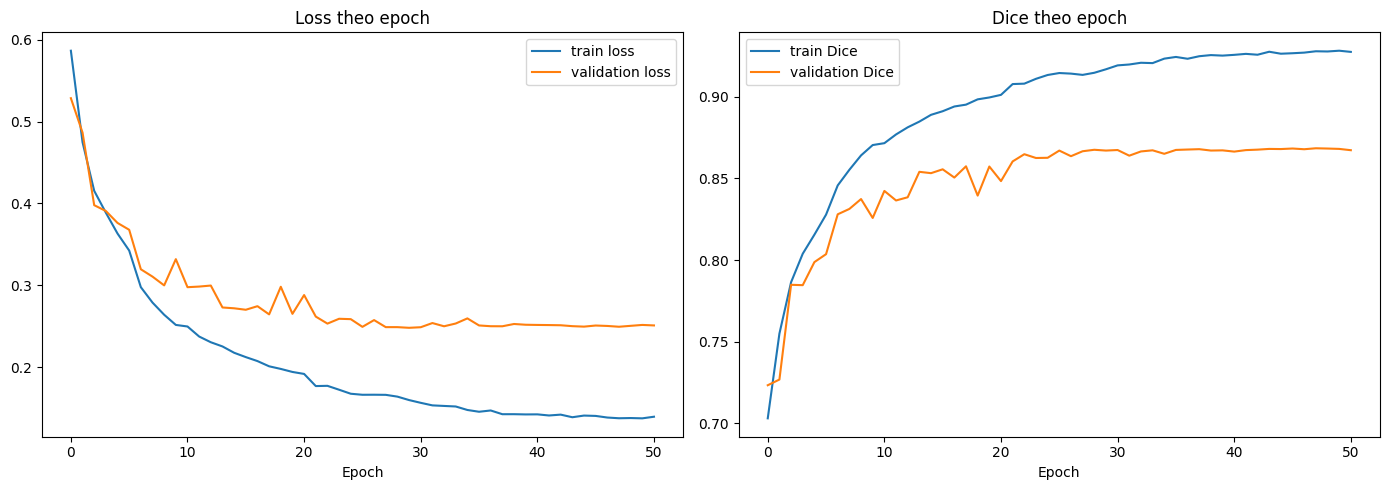

Đã lưu: /content/drive/MyDrive/deeplabv3_stomach/deeplabv3plus_polyp/outputs/figures/training_curves.png


In [23]:
# [Mục đích ô này] Vẽ đường loss/Dice theo epoch để kiểm tra overfitting và lưu hình vào outputs/figures.
def plot_training_curves(csv_path: Path) -> None:
    history = pd.read_csv(csv_path)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["epoch"], history["loss"], label="train loss")
    if "val_loss" in history:
        axes[0].plot(history["epoch"], history["val_loss"], label="validation loss")
    axes[0].set_title("Loss theo epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["epoch"], history["dice_coefficient"], label="train Dice")
    if "val_dice_coefficient" in history:
        axes[1].plot(history["epoch"], history["val_dice_coefficient"], label="validation Dice")
    axes[1].set_title("Dice theo epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    figure_path = FIGURE_ROOT / "training_curves.png"
    plt.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Đã lưu:", figure_path)

plot_training_curves(TRAIN_LOG_DEV)


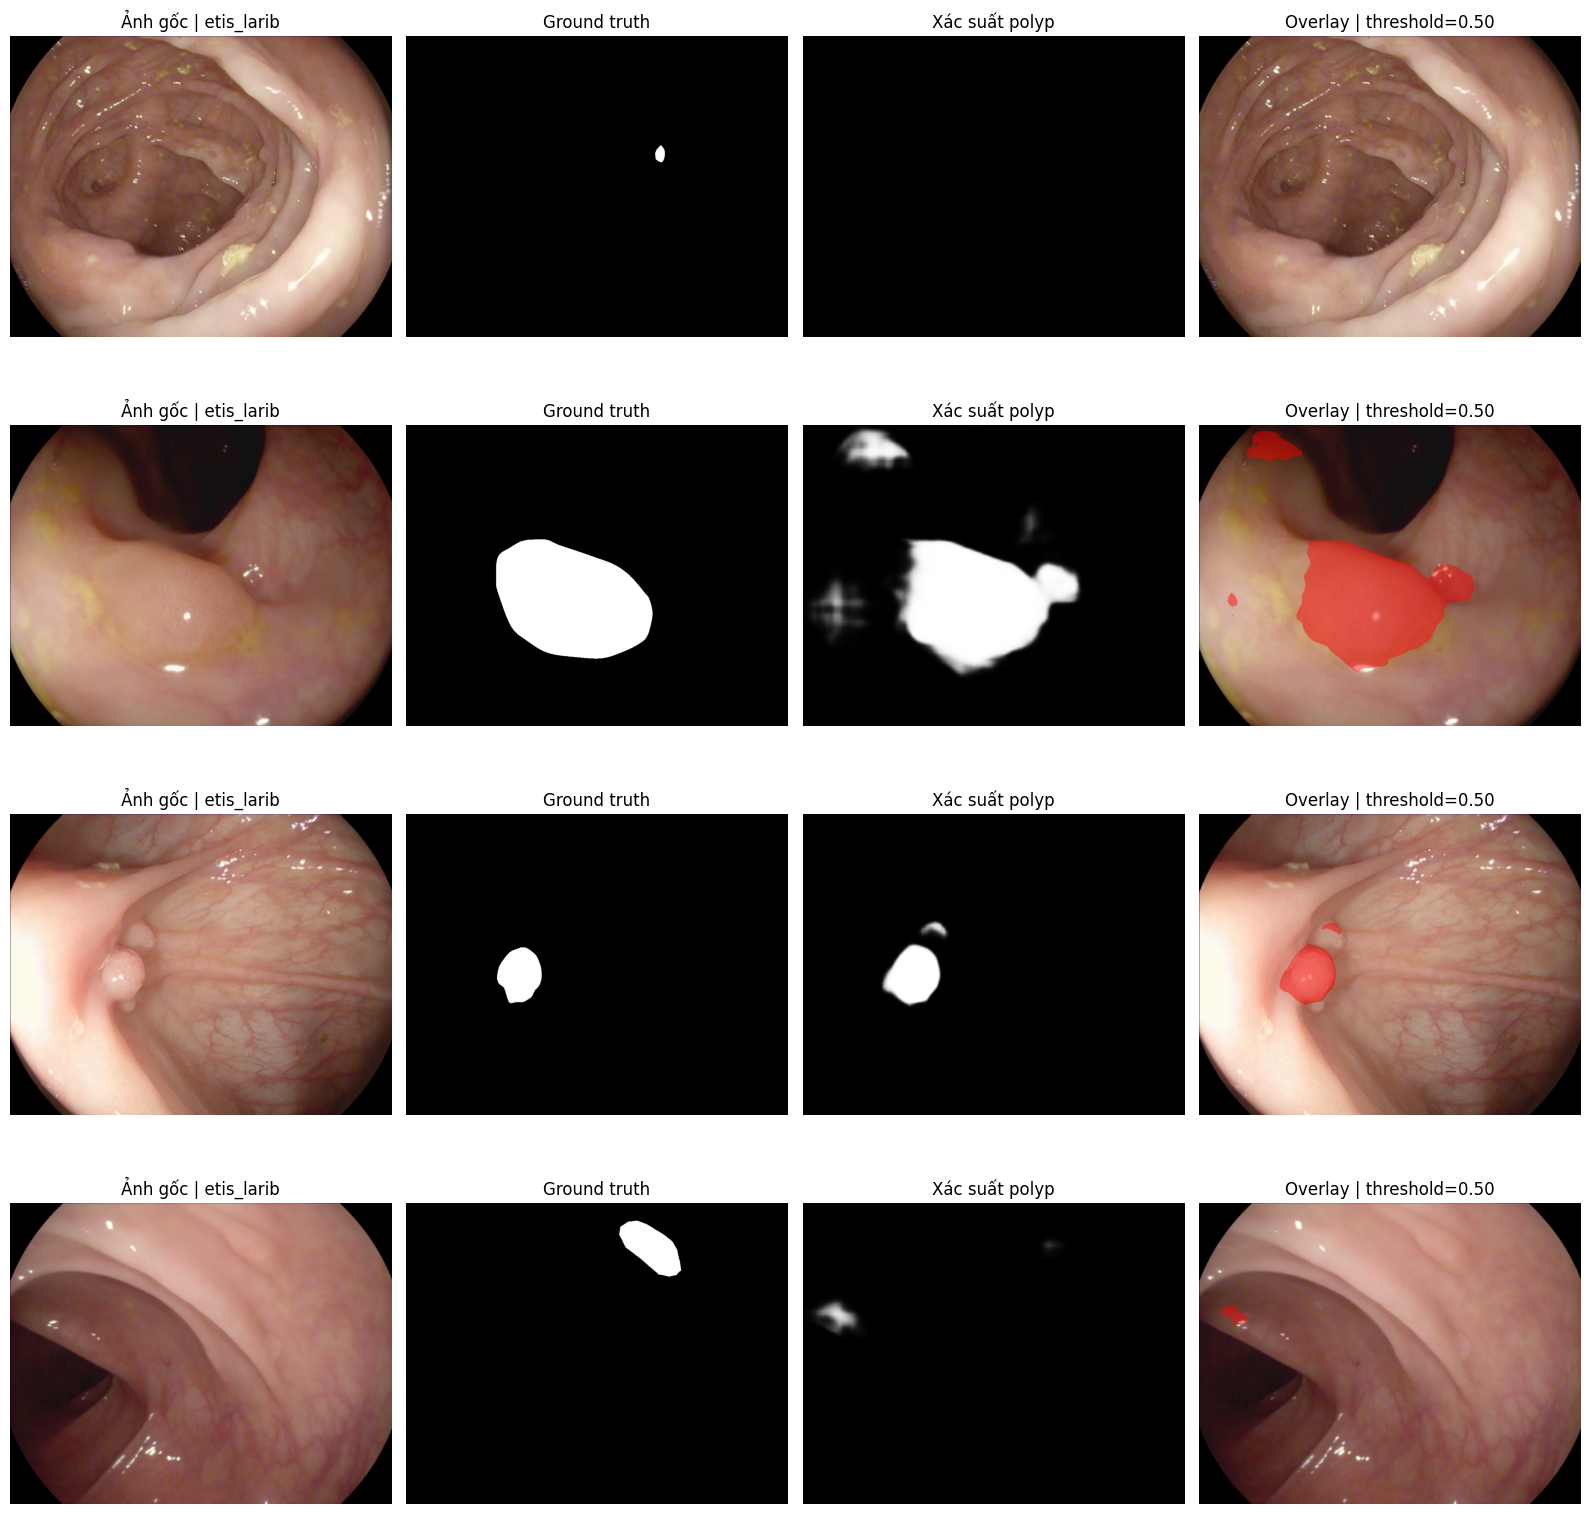

In [25]:
# [Mục đích ô này] Hiển thị ảnh gốc, mask thật, mask dự đoán và overlay để kiểm tra trực quan chất lượng phân đoạn.
def load_prepared_pair(record: pd.Series) -> Tuple[np.ndarray, np.ndarray]:
    image = np.asarray(Image.open(record["prepared_image_path"]).convert("RGB"))
    mask = np.asarray(Image.open(record["prepared_mask_path"]).convert("L")) > 0
    return image, mask

def predict_mask_from_image_array(model: keras.Model, image: np.ndarray, threshold: float) -> Tuple[np.ndarray, np.ndarray]:
    resized = tf.image.resize(tf.cast(image, tf.float32), (IMAGE_SIZE, IMAGE_SIZE), method="bilinear")
    probabilities = model(tf.expand_dims(resized, axis=0), training=False).numpy()[0, :, :, 0]
    probabilities_original = tf.image.resize(
        probabilities[..., np.newaxis],
        (image.shape[0], image.shape[1]),
        method="bilinear",
    ).numpy()[..., 0]
    return probabilities_original, probabilities_original >= threshold

def create_overlay(image: np.ndarray, mask: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    overlay = image.copy()
    color = np.array([255, 0, 0], dtype=np.float32)
    overlay[mask] = ((1.0 - alpha) * overlay[mask].astype(np.float32) + alpha * color).astype(np.uint8)
    return overlay

def show_predictions(frame: pd.DataFrame, n: int = 4, seed: int = SEED) -> None:
    examples = frame.sample(n=min(n, len(frame)), random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(len(examples), 4, figsize=(16, 4 * len(examples)))
    if len(examples) == 1:
        axes = np.expand_dims(axes, axis=0)
    for row_index, row in examples.iterrows():
        image, truth = load_prepared_pair(row)
        probability, prediction = predict_mask_from_image_array(model_for_evaluation, image, best_threshold)
        overlay = create_overlay(image, prediction)

        axes[row_index, 0].imshow(image)
        axes[row_index, 0].set_title(f"Ảnh gốc | {row['source']}")
        axes[row_index, 1].imshow(truth, cmap="gray")
        axes[row_index, 1].set_title("Ground truth")
        axes[row_index, 2].imshow(probability, cmap="gray", vmin=0, vmax=1)
        axes[row_index, 2].set_title("Xác suất polyp")
        axes[row_index, 3].imshow(overlay)
        axes[row_index, 3].set_title(f"Overlay | threshold={best_threshold:.2f}")
        for axis in axes[row_index]:
            axis.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(etis_test_df, n=4)


In [27]:
# [Mục đích ô này] Lưu cấu hình train và kiểm tra các artifact cuối cùng
# để dùng cho backend DeepLabV3+.

DATASET_SOURCES = {
    "kvasir_seg": "Kvasir-SEG",
    "cvc_clinicdb": "CVC-ClinicDB",
    "etis_larib": "ETIS-LaribPolypDB",
}

training_config = {
    "model": "DeepLabV3+ with ResNet50 encoder",
    "task": "binary polyp segmentation",
    "image_size": int(IMAGE_SIZE),
    "threshold_selected_on_validation": float(best_threshold),
    "sources": DATASET_SOURCES,
    "train_pool": {
        "kvasir_seg": 900,
        "cvc_clinicdb": 550,
    },
    "internal_test": {
        "kvasir_seg": 100,
        "cvc_clinicdb": 62,
    },
    "external_test": {
        "etis_larib": 190,
    },
    "seed": int(SEED),
    "final_model_file": FINAL_MODEL_PATH.name,
}

config_path = OUTPUT_ROOT / "training_config.json"

with config_path.open("w", encoding="utf-8") as file:
    json.dump(training_config, file, ensure_ascii=False, indent=2)

print("Đã lưu cấu hình:", config_path)

print("\nArtifacts trong outputs:")
for path in sorted(OUTPUT_ROOT.iterdir()):
    print("-", path.name)

print("\nModels đã tạo:")
for path in sorted(MODEL_ROOT.iterdir()):
    print("-", path.name)

print("\nModel dùng cho backend:", FINAL_MODEL_PATH)
print("Threshold dùng cho backend:", f"{best_threshold:.2f}")

Đã lưu cấu hình: /content/drive/MyDrive/deeplabv3_stomach/deeplabv3plus_polyp/outputs/training_config.json

Artifacts trong outputs:
- figures
- per_image_test_metrics.csv
- summary_test_metrics.csv
- threshold_search_validation.csv
- training_config.json
- training_log_development.csv

Models đã tạo:
- deeplabv3plus_polyp_dev_best.keras
- deeplabv3plus_polyp_final_benchmark.keras

Model dùng cho backend: /content/drive/MyDrive/deeplabv3_stomach/deeplabv3plus_polyp/models/deeplabv3plus_polyp_final_benchmark.keras
Threshold dùng cho backend: 0.50
